# Motif hit calling analysis

Analyze finemo motif hit calling results across 22 cell types.
Inspired by Nair et al. (fibroblast reprogramming, media-5.pdf) and Metzl-Raz et al. (cardiac organoid differentiation).

Key analyses:
1. Hit quality metrics (similarity, coefficient distributions)
2. Total motif instance counts per cell type (shared vs specific TFs)
3. Importance-weighted motif composition (hit_coefficient_global)
4. Differential motif usage heatmap across cell types

# Set-up

In [1]:
import os
import glob
import numpy as np
import pandas as pd

import logomaker as lm
from tangermeme.io import read_meme

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
dataset = "sc-islet-differentiation_10X-Multiome"
base_dir = f"/cellar/users/aklie/data/datasets/{dataset}"
results_dir = f"{base_dir}/results/3_single_task_models"

# Motif annotations
path_motif_file = f"{results_dir}/motifs/gimme_cluster/meme/combined.meme"
path_motif_annotation = f"{results_dir}/motifs/gimme_cluster/tfs_initial.txt"

path_out = f"{results_dir}/motifs/gimme_cluster/hits/unified"
os.makedirs(path_out, exist_ok=True)

# Cell type colors and order
cell_type_meta = pd.read_csv(f"{base_dir}/config/cell_type_metadata.tsv", sep="\t")
color_dict = dict(zip(cell_type_meta["cell_type"], cell_type_meta["color"]))
celltype_order = cell_type_meta["cell_type"].tolist()

# Load motif annotations
motif_dict = read_meme(path_motif_file)
initial_motifs = pd.read_csv(path_motif_annotation, sep="\t", header=None)
initial_motifs.columns = ["cluster_name", "top_tomtom_annotation", "evalue"]
annotation_dict = initial_motifs.set_index("cluster_name")["top_tomtom_annotation"].to_dict()

# Load hit calling results

In [3]:
# Aggregate hits per-file to avoid OOM
# Using UNIFIED hits (clustered motif names, lambda=0.8)
hit_files = sorted(glob.glob(f"{results_dir}/*/average/motifs/hits/counts_unified/hits.tsv"))
print(f"Found {len(hit_files)} cell types with unified hit calling results")

# Pre-aggregate: for each cell type, compute per-motif stats without loading all into memory
count_rows = []
importance_rows = []
qc_rows = []
similarity_samples = {}  # subsample for QC distributions

for f in hit_files:
    celltype = f.split("/")[-6]
    if celltype not in color_dict:
        continue
    
    df = pd.read_csv(f, sep="\t")
    
    # QC stats
    qc_rows.append({
        "celltype": celltype,
        "n_hits": len(df),
        "n_peaks": df["peak_id"].nunique(),
        "median_similarity": df["hit_similarity"].median(),
        "mean_coefficient": df["hit_coefficient"].mean(),
        "mean_coefficient_global": df["hit_coefficient_global"].mean(),
        "median_importance": df["hit_importance"].median(),
    })
    
    # Subsample for distribution plots (10k per cell type)
    similarity_samples[celltype] = df["hit_similarity"].sample(min(10000, len(df)), random_state=42).values
    
    # Per-motif aggregates
    grouped = df.groupby("motif_name")
    count_rows.append(grouped.size().rename(celltype))
    importance_rows.append(grouped["hit_coefficient_global"].sum().rename(celltype))
    
    print(f"  {celltype}: {len(df):,} hits, {df['peak_id'].nunique():,} peaks")
    del df  # free memory

# Build matrices
count_matrix = pd.DataFrame(count_rows).fillna(0).astype(int)
importance_matrix = pd.DataFrame(importance_rows).fillna(0)
qc = pd.DataFrame(qc_rows).set_index("celltype")

# Reorder by cell type
ct_order = [ct for ct in celltype_order if ct in count_matrix.index]
count_matrix = count_matrix.reindex(ct_order)
importance_matrix = importance_matrix.reindex(ct_order)
qc = qc.reindex(ct_order)
qc["hits_per_peak"] = qc["n_hits"] / qc["n_peaks"]

# Motif annotations — now using unified cluster names (Average_131, etc.)
motif_annotations = {m: annotation_dict.get(m, m).split('_')[0] for m in count_matrix.columns}

print(f"\nCount matrix: {count_matrix.shape[0]} cell types x {count_matrix.shape[1]} motifs")
print(f"Total motif instances: {count_matrix.sum().sum():,}")
print(f"Motif names (first 10): {list(count_matrix.columns[:10])}")

Found 22 cell types with unified hit calling results


  DE: 1,130,182 hits, 362,701 peaks


  ENP_phase1: 647,143 hits, 140,110 peaks


  FB_FLT1: 475,240 hits, 101,395 peaks


  PFG1: 964,097 hits, 228,094 peaks


...

  late_SC_EC: 726,802 hits, 178,744 peaks


  late_SC_alpha: 640,050 hits, 154,305 peaks


  late_SC_beta: 808,435 hits, 189,812 peaks


  liver: 833,158 hits, 233,876 peaks


  proliferating_endocrine: 485,716 hits, 95,437 peaks

Count matrix: 22 cell types x 70 motifs
Total motif instances: 18,075,007
Motif names (first 10): ['Average_131', 'Average_168', 'Average_234', 'Average_436', 'Average_501', 'Average_508', 'Average_525', 'Average_554', 'Average_561', 'Average_566']


# Hit quality metrics

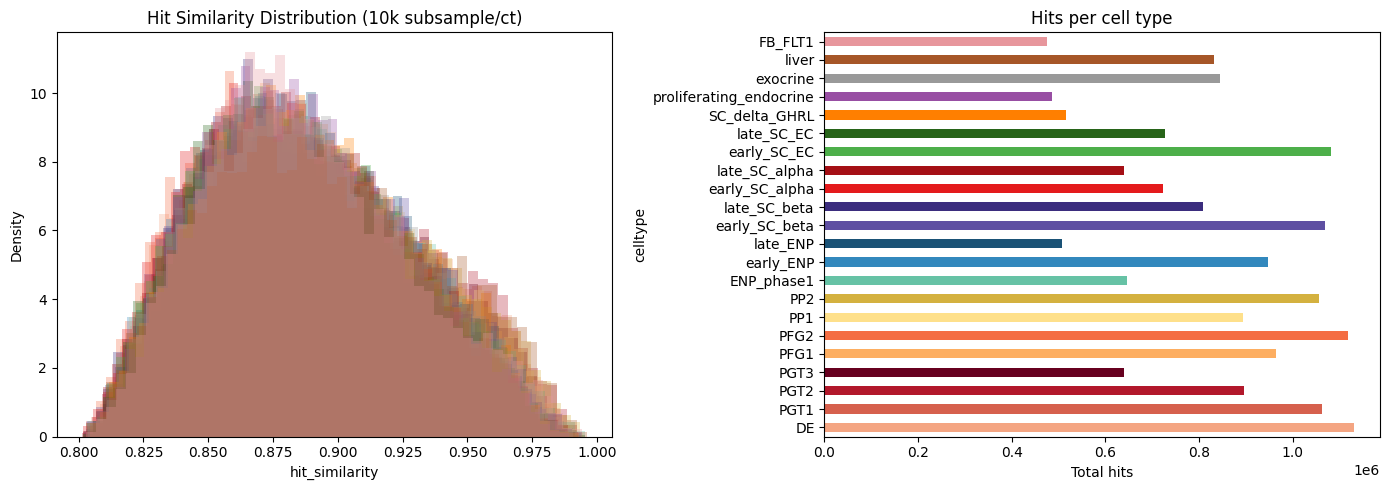

In [4]:
# Distribution of hit_similarity using subsampled data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hit similarity distribution (subsampled)
for ct in ct_order:
    if ct in similarity_samples:
        axes[0].hist(similarity_samples[ct], bins=50, alpha=0.3, color=color_dict[ct], density=True)
axes[0].set_xlabel('hit_similarity')
axes[0].set_ylabel('Density')
axes[0].set_title('Hit Similarity Distribution (10k subsample/ct)')

# Hits per cell type
colors = [color_dict[ct] for ct in qc.index]
qc['n_hits'].plot.barh(ax=axes[1], color=colors)
axes[1].set_xlabel('Total hits')
axes[1].set_title('Hits per cell type')

plt.tight_layout()
plt.savefig(f"{path_out}/hit_quality_distributions.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# QC summary (already computed during loading)
qc.to_csv(f"{path_out}/hit_quality_summary.csv")
print(f"Median hits per peak: {qc['hits_per_peak'].median():.1f}")
qc

Median hits per peak: 4.1


,n_hits,n_peaks,median_similarity,mean_coefficient,mean_coefficient_global,median_importance,hits_per_peak
celltype,,,,,,,
DE,1130182,362701,0.886816,5.005415,0.000519,0.078342,3.116016
PGT1,1063771,305482,0.882008,5.194616,0.000709,0.076127,3.482271
PGT2,897173,224289,0.891090,5.631800,0.000975,0.101691,4.000076
PGT3,640212,156608,0.887587,5.546190,0.000574,0.084414,4.087990
PFG1,964097,228094,0.885230,5.104575,0.000570,0.083836,4.226753
PFG2,1119073,331818,0.878960,4.464100,0.000564,0.072174,3.372551
PP1,894974,223614,0.885878,5.217460,0.000640,0.076405,4.002316
PP2,1056961,266372,0.889254,5.891878,0.001027,0.101935,3.967988
ENP_phase1,647143,140110,0.885851,5.191839,0.000565,0.074033,4.618821


# Motif instance count matrix

Total number of motif hits per motif per cell type. Shows which TFs are broadly used vs cell-type-specific.

In [6]:
# Count and importance matrices already computed during loading
print(f"Count matrix: {count_matrix.shape[0]} cell types x {count_matrix.shape[1]} motifs")
print(f"Total motif instances: {count_matrix.sum().sum():,}")
print(f"\nImportance matrix: {importance_matrix.shape}")

# Normalize to proportions
importance_frac = importance_matrix.div(importance_matrix.sum(axis=1), axis=0)

Count matrix: 22 cell types x 70 motifs
Total motif instances: 18,075,007

Importance matrix: (22, 70)


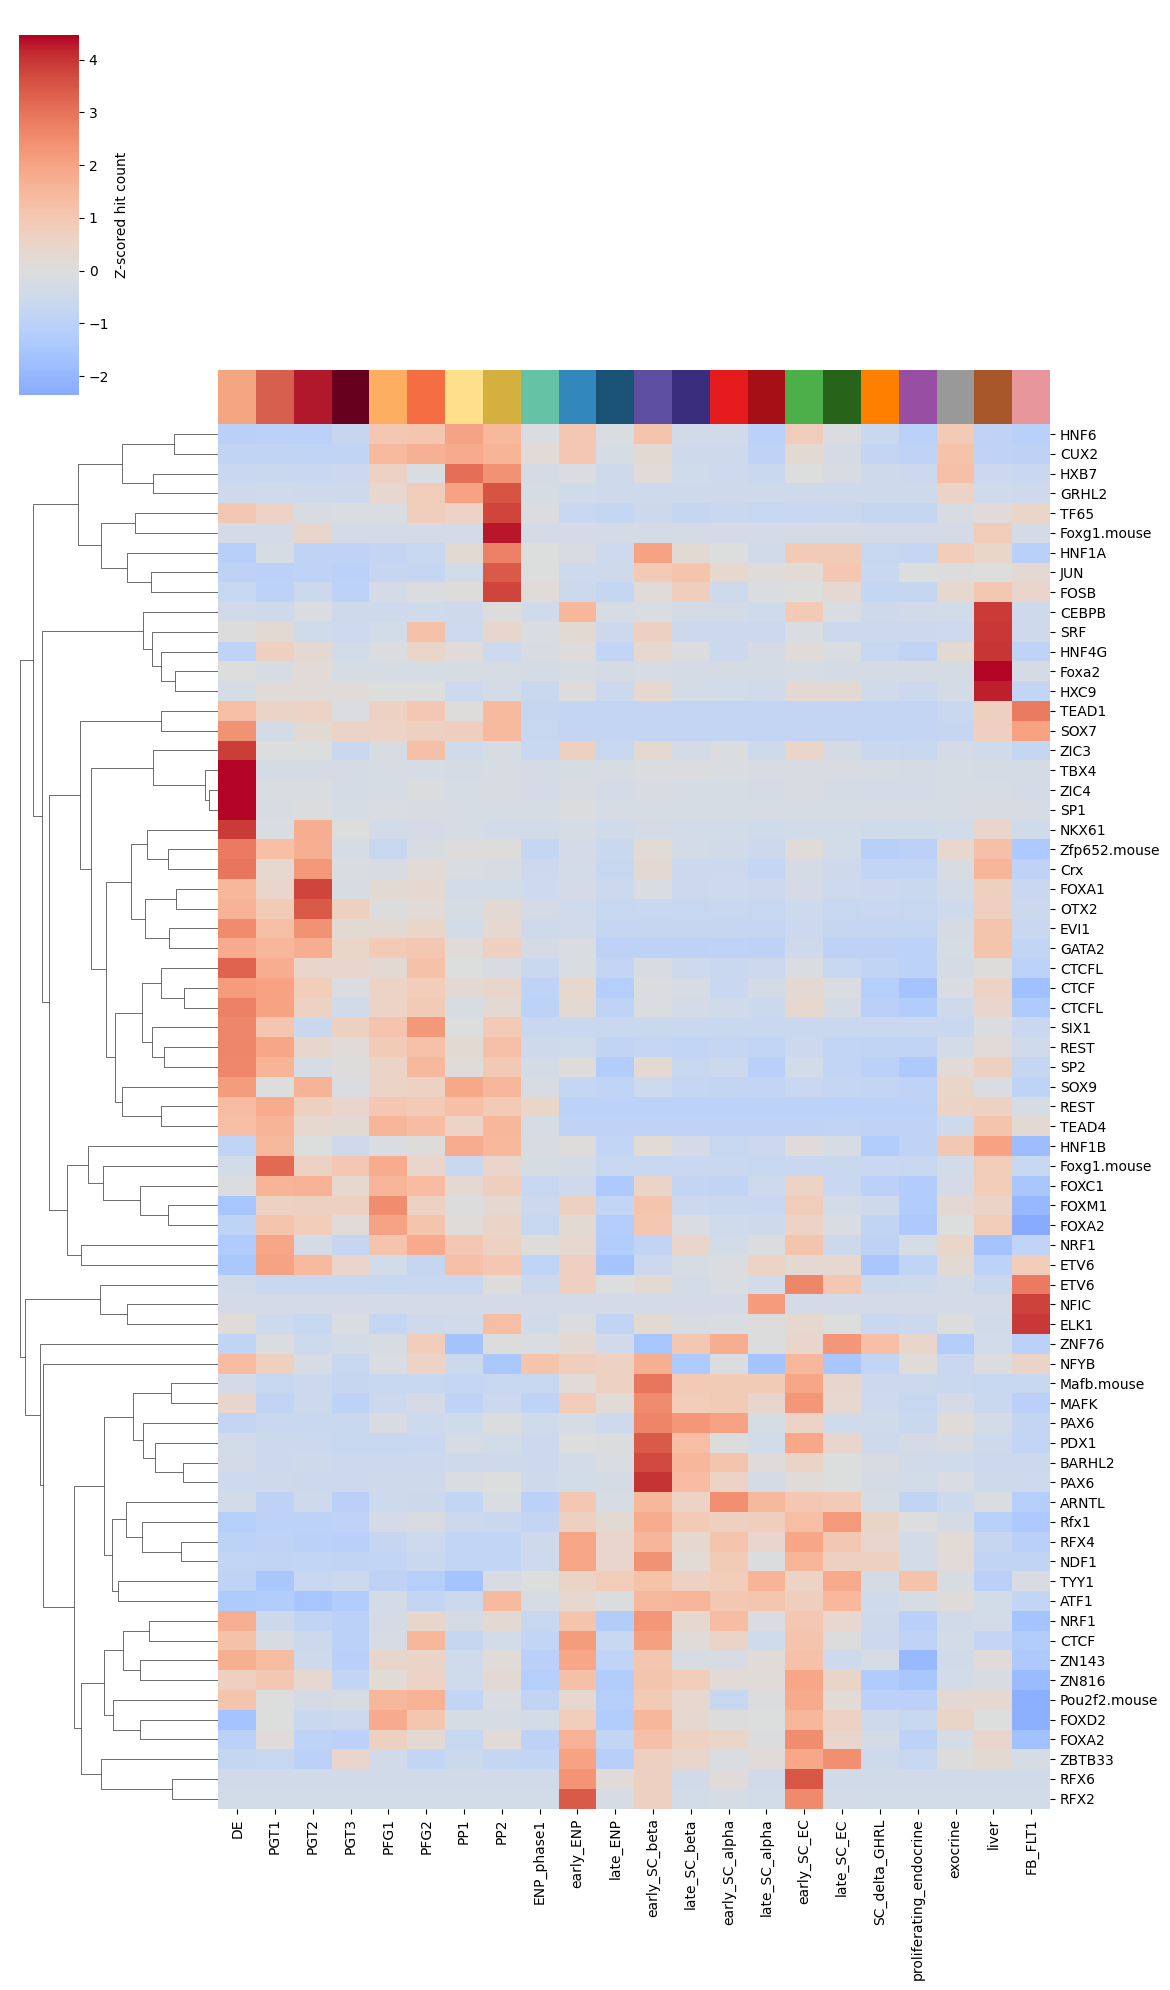

In [7]:
# Z-score across cell types for visualization
count_z = (count_matrix - count_matrix.mean(axis=0)) / count_matrix.std(axis=0)
count_z = count_z.fillna(0)

# Clustermap
row_colors = [color_dict.get(ct, '#999999') for ct in count_z.index]

g = sns.clustermap(
    count_z.T,
    cmap="coolwarm",
    center=0,
    figsize=(12, 20),
    row_cluster=True,
    col_cluster=False,
    col_colors=row_colors,
    cbar_kws={"label": "Z-scored hit count"},
    yticklabels=[motif_annotations.get(m, m) for m in count_z.columns],
)
g.ax_heatmap.set_ylabel('')
plt.savefig(f"{path_out}/hit_count_clustermap.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Importance-weighted motif composition

Using `hit_coefficient_global` (coefficient scaled by importance) to capture the functional weight of each motif, not just occurrence.

In [8]:
# Top motifs by total importance across all cell types
print(f"Importance matrix: {importance_matrix.shape}")
print(f"\nTop motifs by total importance (hit_coefficient_global):")
top_motifs = importance_matrix.sum(axis=0).sort_values(ascending=False).head(15)
for m, v in top_motifs.items():
    print(f"  {motif_annotations.get(m, m):20s} ({m}): {v:.6f}")

Importance matrix: (22, 70)

Top motifs by total importance (hit_coefficient_global):
  CTCF                 (Average_664): 5352.731031
  SP2                  (Average_658): 857.158817
  RFX4                 (Average_597): 722.375660
  GATA2                (Average_654): 655.713820
  FOXA2                (Average_625): 627.976146
  HNF1B                (Average_508): 528.252300
  NRF1                 (Average_623): 501.702240
  FOSB                 (Average_657): 409.570885
  NFYB                 (Average_525): 359.518310
  NDF1                 (Average_662): 295.148811
  HNF6                 (Average_580): 293.378264
  TEAD4                (Average_660): 273.382098
  PDX1                 (Average_665): 256.864680
  NRF1                 (Average_637): 241.693446
  Rfx1                 (Average_653): 224.796634


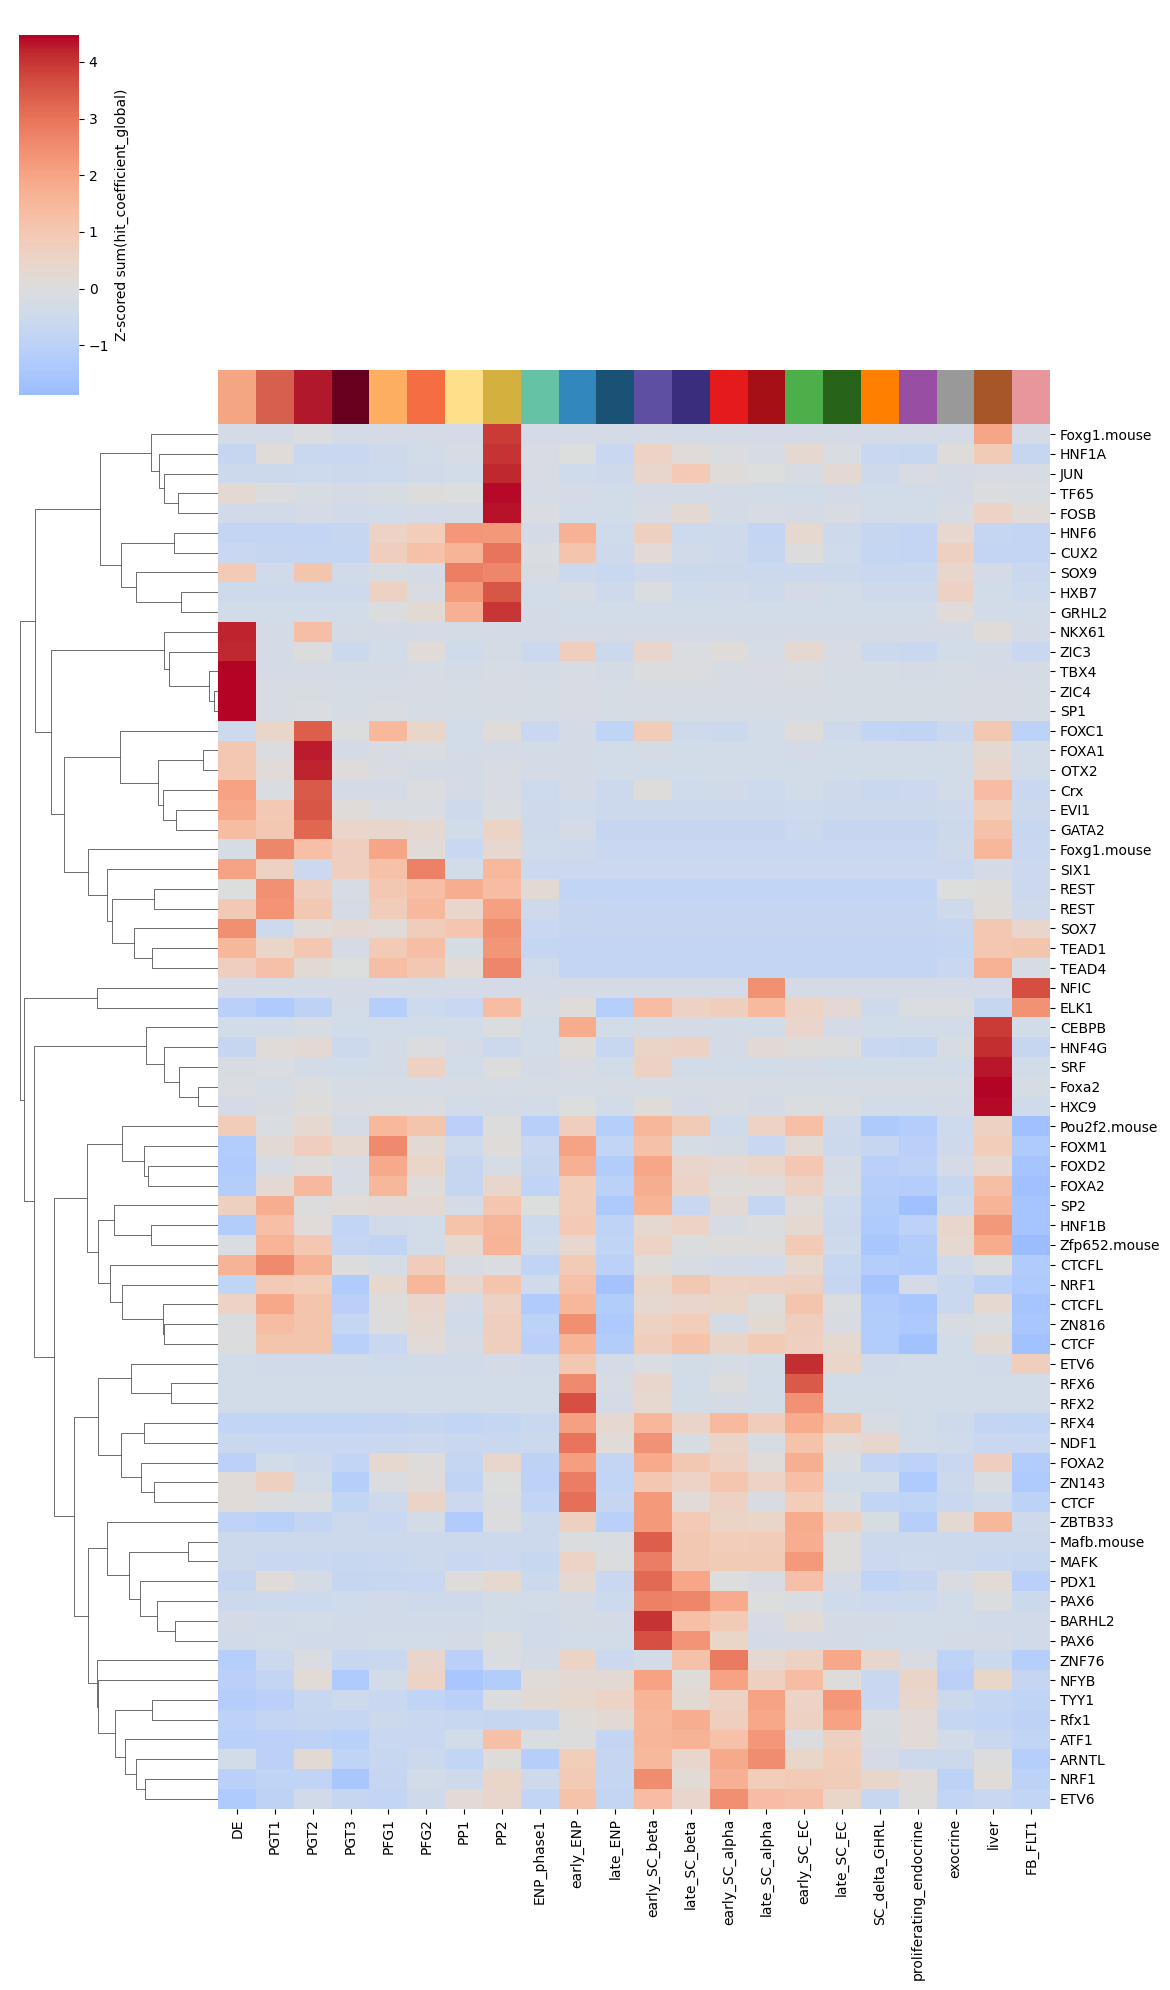

In [9]:
# Z-score the importance matrix across cell types
imp_z = (importance_matrix - importance_matrix.mean(axis=0)) / importance_matrix.std(axis=0)
imp_z = imp_z.fillna(0)

g = sns.clustermap(
    imp_z.T,
    cmap="coolwarm",
    center=0,
    figsize=(12, 20),
    row_cluster=True,
    col_cluster=False,
    col_colors=row_colors,
    cbar_kws={"label": "Z-scored sum(hit_coefficient_global)"},
    yticklabels=[motif_annotations.get(m, m) for m in imp_z.columns],
)
g.ax_heatmap.set_ylabel('')
plt.savefig(f"{path_out}/hit_importance_clustermap.pdf", dpi=300, bbox_inches="tight")
plt.show()

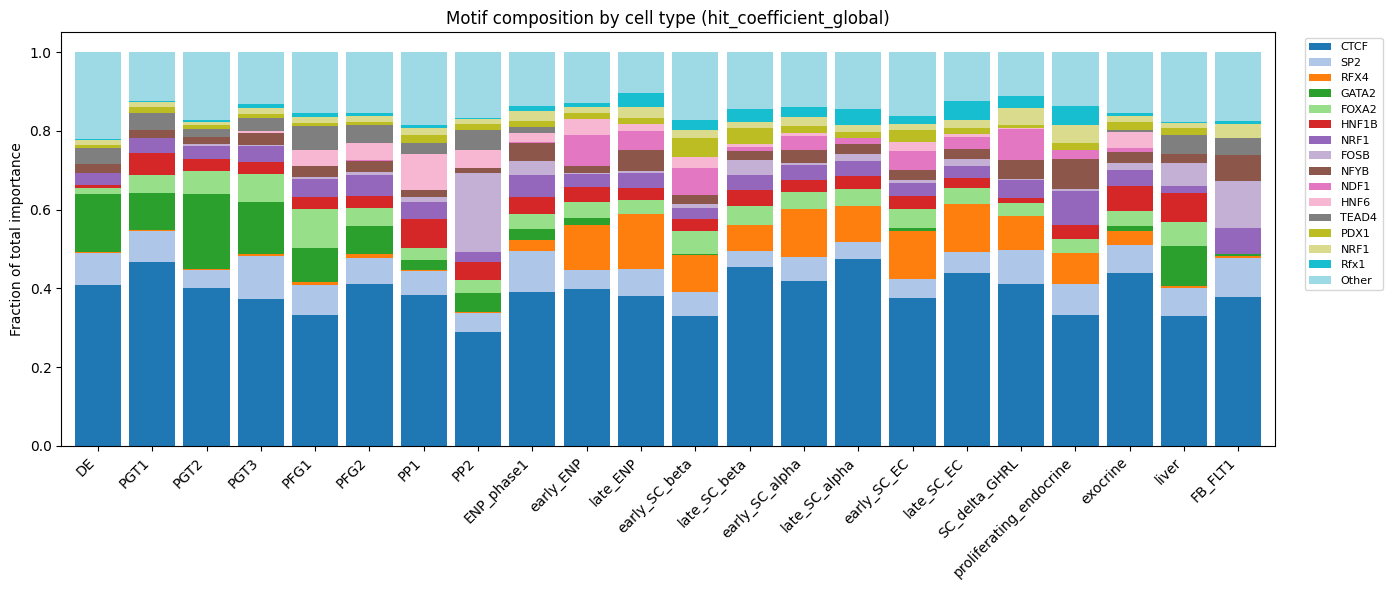

In [10]:
# Proportional motif composition — stacked barplot (top 15 motifs + 'other')
top_n = 15
top_motif_names = importance_matrix.sum(axis=0).sort_values(ascending=False).head(top_n).index.tolist()
other_cols = [c for c in importance_frac.columns if c not in top_motif_names]

plot_df = importance_frac[top_motif_names].copy()
plot_df['Other'] = importance_frac[other_cols].sum(axis=1)

# Rename columns to annotations
plot_df.columns = [motif_annotations.get(m, m) if m != 'Other' else 'Other' for m in plot_df.columns]

fig, ax = plt.subplots(figsize=(14, 6))
plot_df.plot.bar(stacked=True, ax=ax, colormap='tab20', width=0.85)
ax.set_ylabel('Fraction of total importance')
ax.set_title('Motif composition by cell type (hit_coefficient_global)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{path_out}/motif_composition_barplot.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Save results

In [11]:
# Save matrices
count_matrix.to_csv(f"{path_out}/hit_count_matrix.csv")
importance_matrix.to_csv(f"{path_out}/hit_importance_matrix.csv")
importance_frac.to_csv(f"{path_out}/hit_importance_fraction.csv")
count_z.to_csv(f"{path_out}/hit_count_zscore.csv")
imp_z.to_csv(f"{path_out}/hit_importance_zscore.csv")

print(f"Saved to {path_out}")

Saved to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/hit_analysis_unified


# DONE!